In [80]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
import cc3d 

In [ ]:
def delta_E_total(array,nnn_array,i,J=1,h=0,nnn=False):
    N=len(array)
    delta_E = -2*array[i]*(array[(i+1)%N]+array[i-1])
    
    if nnn==True:
        shuffle_index = np.argwhere(nnn_array==i)[0]
        up_index = nnn_array[(shuffle_index+1)%N]
        down_index = nnn_array[(shuffle_index-1)%N]
        delta_E += -2*array[i]*(array[(up_index)%N]+array[down_index])

    delta_E *= -J
    delta_E += 2*h*array[i]
    return delta_E   

def nn_sim(N_site,T,n_max=10**3,skip=10,J=1,h=0):
    array = 2*random.randint(2,size=N_site)-1

    E = [0]
    m = [np.sum(array)]
    current_energy=0

    # prepare random numbers
    index = random.randint(N_site,size=n_max)
    select = random.rand(n_max)

    for l in range(n_max):
        i = index[l]
        delta_E=delta_E_total(array,[],i,h=h)
        prev_energy = current_energy
        if delta_E <= 0 or select[l] < np.exp(-delta_E/T):
            array[i]*=-1
            current_energy = prev_energy+delta_E
        else:
            current_energy = prev_energy
        
        if l%skip==0:
            #print(delta_E,selection)
            E.append(current_energy)
            m.append(np.sum(array))
            #print(delta_E,selection)

    E = np.array(E)/N_site
    m = np.array(m)/N_site

    return E,m,array


In [100]:
T_list = np.linspace(10**-5,70,300)

E_mean_list = []
m_mean_list = []
domain_mean_list = []

for index, T in enumerate(T_list):
    T=2
    N_site=1000
    n_max = 10**2*N_site
    n_0 = n_max/4
    skip=20
    h=0


    E,m,final_array=nn_sim(N_site,T,n_max=n_max,skip=20,h=h)
    labels = cc3d.connected_components(final_array,connectivity=6)
    sizes = np.bincount(labels)[1:]
    #fig.tight_layout()

    E_mean = np.mean(E[int(len(E)/3):])
    m_mean = np.mean(m[int(len(m)/3):])
    domain_mean_list.append(np.mean(sizes))
    E_mean_list.append(E_mean)
    m_mean_list.append(m_mean)

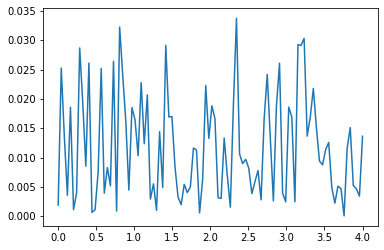

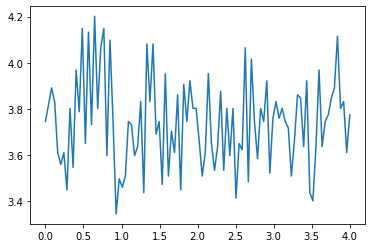

In [96]:
plt.plot(T_list,abs(np.array(m_mean_list)))
plt.show()
plt.plot(T_list,domain_mean_list)

In [98]:
n_max = 10**6
T=10
N_site=1000
h=0
skip=10
n_0 = n_max/4

E,m,final_array=nn_sim(N_site,T,n_max=n_max,skip=skip,h=h)

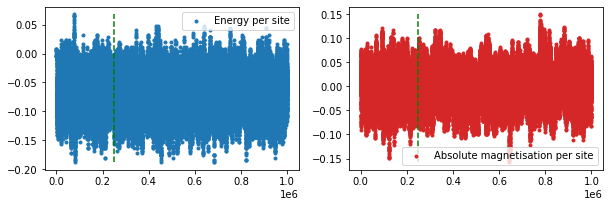

In [99]:
n_0 = n_max/4
fig,(ax0,ax1) = plt.subplots(1,2,figsize=(10,3))
ax0.scatter(np.arange(len(m))*skip,E,marker='.',label="Energy per site")
ax1.scatter(np.arange(len(m))*skip,m,marker='.',label="Absolute magnetisation per site",color="tab:red")
ax0.plot([n_0,n_0],[min(E),max(E)],linestyle="dashed",color="green")
ax1.plot([n_0,n_0],[min(m),max(m)],linestyle="dashed",color="green")
#ax2.imshow(final_array)
ax0.legend()
ax1.legend()
#fig.tight_layout()
plt.show()


In [109]:
N = 10
i = 9
j = 1
print(((i-1)%N-j),(i+1)%N-j)

7 -1


In [145]:
N_site = 1000
index = np.arange(N_site)
shuffle = [0]
for i in range(1,N_site):
    choices = [x for x in index if (x not in shuffle) and (((x-1)%N-shuffle[-1]!=0)) and (((x+1)%N-shuffle[-1]!=0))]
    choice = random.choice(choices)
    shuffle.append(choice)

print(shuffle)
shuffle = np.array(shuffle)

[0, 190, 624, 275, 998, 606, 126, 202, 617, 378, 404, 97, 116, 978, 997, 920, 987, 855, 433, 118, 417, 331, 632, 254, 738, 584, 51, 917, 386, 831, 338, 812, 757, 431, 81, 741, 924, 316, 546, 921, 283, 313, 732, 789, 38, 452, 819, 510, 483, 717, 296, 158, 389, 545, 937, 471, 350, 91, 840, 945, 276, 887, 553, 679, 428, 791, 302, 65, 681, 421, 481, 167, 844, 333, 54, 204, 360, 834, 515, 810, 971, 239, 152, 14, 131, 101, 402, 127, 380, 488, 112, 504, 303, 349, 794, 555, 420, 191, 139, 790, 671, 485, 208, 196, 730, 918, 371, 903, 469, 706, 446, 829, 572, 374, 779, 884, 744, 136, 227, 277, 197, 507, 583, 255, 641, 279, 405, 86, 792, 760, 697, 768, 137, 898, 432, 619, 278, 871, 71, 786, 104, 174, 123, 457, 665, 764, 486, 125, 575, 965, 430, 455, 615, 765, 217, 114, 895, 224, 748, 47, 676, 726, 37, 590, 265, 957, 373, 911, 149, 935, 229, 367, 586, 8, 551, 950, 179, 292, 257, 348, 10, 106, 419, 609, 120, 713, 464, 867, 662, 436, 195, 280, 969, 64, 506, 411, 247, 561, 100, 648, 266, 325, 366, 58

In [148]:
print(np.argwhere(shuffle==190)[0])

[1]
